# Model Development & Tracking 
Covers **Stage 2.2–2.4 + Stage 3.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 

- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`. 
- *Provided to extend:* `src/model.py`, `src/train.py`, `app.py`. 
- *You build:* this notebook.

### 0. Setup

In [14]:
import config
# TODO: imports (torch, mlflow, pandas, matplotlib) as needed
import warnings
warnings.filterwarnings("ignore")

import json
import sys
import subprocess
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import image as mpimg

import torch
import mlflow
import mlflow.pytorch

import config


def load(path):
    return json.loads(Path(path).read_text())

## **Stage 2.2 — Transfer-Learning Model** <font color="red">[7 marks]</font>

- **2.2.1 — ImageNet-pretrained ResNet18, backbone frozen [4]**
- **2.2.2 — New 2-class head replaces fc (head trained) [3]**

**Objective:** Build an ImageNet-pretrained ResNet18 with a frozen backbone + new 2-class head.

**Implement in:** src/model.build_model

**Inputs → Outputs:** → a torch model; only the head's params have requires_grad=True

**TODO:** load weights=IMAGENET1K + freeze the backbone (2.2.1); replace fc with a 2-class Linear head so only the head trains (2.2.2); print total vs trainable params.

**Depends on:** Stage 2.1 transformations completed in Data_Preparation.ipynb  ·  **Document here:** the param counts (trainable should be ~the head only).

In [15]:
# TODO 2.2.1-2.2.2: from src.model import build_model, trainable_parameters; build + print params
from src.model import build_model, trainable_parameters

model = build_model()

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in trainable_parameters(model))

print("\nTotal Parameters:", total_params)
print("Trainable Parameters:", trainable_params)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## **Stage 2.3 — Training Workflow** <font color="red">[6 marks]</font>

- **2.3.1 — Class-weighted loss + optimiser (trainable params) + seed [3]**
- **2.3.2 — Epoch loop + validation eval + early stopping [3]**

**Objective:** Train the head reproducibly with validation + early stopping.

**Implement in:** src/train.py

**Inputs → Outputs:** splits + model → trained model.pt + model_meta.json

**TODO:** class-weighted CrossEntropy + Adam over TRAINABLE params only + seed 42 (2.3.1); epoch loop with val evaluation + early stop on val-F1 (2.3.2).

**Document here:** the training summary (final val F1, epochs).

In [16]:
# TODO 2.3.1-2.3.2: !python -m src.train   (then load artifacts/model_meta.json)
!python -m src.train

[data] root = C:\Users\SiddhantPanigrahi\Downloads\Negative_Case_1_MLOps_2\data\casting_data
[data] 7348 images | quality passed = True | duplicates = 64
[data] splits: train=5639, val=994, test=715
[train] using 2500 train images (cap=2500)
[epoch 1] loss=0.5264 val_acc=0.9064 val_f1=0.9158 val_recall=0.8988
[epoch 2] loss=0.3926 val_acc=0.9195 val_f1=0.9269 val_recall=0.9005
[epoch 3] loss=0.3329 val_acc=0.9306 val_f1=0.9393 val_recall=0.9485
[epoch 4] loss=0.3052 val_acc=0.9245 val_f1=0.9326 val_recall=0.9218
[test] {'accuracy': 0.9315, 'precision_defect': 0.9591, 'recall_defect': 0.9316, 'f1_defect': 0.9451, 'macro_f1': 0.9269, 'roc_auc': 0.9819, 'confusion_matrix': [[244, 18], [31, 422]], 'n': 715}
[mlflow] registered casting_defect_classifier v1
[drift] saved reference baseline (400 clean images)
[done] training complete


2026/06/26 15:39:29 INFO mlflow.tracking.fluent: Experiment with name 'casting_defect_detection' does not exist. Creating a new experiment.
2026/06/26 15:49:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'casting_defect_classifier'.
Created version '1' of model 'casting_defect_classifier'.


In [23]:
meta = load(config.MODEL_META_PATH)

print("Registered Model :", meta["registered_model"])
print("Run ID :", meta["run_id"])
print("Validation F1 :", meta["val_f1_defect"])

print("\nTest Metrics")
print(meta["test_metrics"])

Registered Model : casting_defect_classifier
Run ID : 1b4df7ec51ca4e89894d5b57f829c7aa
Validation F1 : 0.9393

Test Metrics
{'accuracy': 0.9315, 'precision_defect': 0.9591, 'recall_defect': 0.9316, 'f1_defect': 0.9451, 'macro_f1': 0.9269, 'roc_auc': 0.9819, 'confusion_matrix': [[244, 18], [31, 422]], 'n': 715}


## **Stage 2.4 — MLflow Experiment Tracking** <font color="red">[6 marks]</font>

- **2.4.1 — Params + per-epoch metrics logged [3]**
- **2.4.2 — Trained model logged to the run [3]**

**Objective:** Track the experiment in MLflow.

**Implement in:** src/train.py (mlflow calls)

**Inputs → Outputs:** training run → MLflow params + per-epoch metrics + logged model

**TODO:** set_experiment; log_params; log_metrics(step=epoch) (2.4.1); log_model (2.4.2).

**Document here:** the runs table (mlflow.search_runs).

In [24]:
# TODO 2.4.1-2.4.2: mlflow.search_runs(experiment_names=[config.MLFLOW_EXPERIMENT])
mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)
runs = mlflow.search_runs(experiment_names=[config.MLFLOW_EXPERIMENT])
cols = [c for c in runs.columns
    if c.startswith("metrics.test_") or c == "tags.mlflow.runName"][:8]
print("Runs Logged:", len(runs))
runs[cols].head()

Runs Logged: 1


,metrics.test_roc_auc,metrics.test_accuracy,metrics.test_f1_defect,metrics.test_precision_defect,metrics.test_n,metrics.test_recall_defect,metrics.test_macro_f1,tags.mlflow.runName
0,0.9819,0.9315,0.9451,0.9591,715.0,0.9316,0.9269,capable-auk-759


## **Stage 3.1 — Evaluation & Failure Analysis** <font color="red">[7 marks]</font>

- **3.1.1 — Imbalance-aware metrics + model selection [4]**
- **3.1.2 — Confusion/ROC plots + failure-case analysis [3]**

**Objective:** Evaluate on defect recall/F1, not accuracy.

**Implement in:** src/evaluate.py

**Inputs → Outputs:** model + test split → metrics.json + model_eval.png

**TODO:** report recall(defect)/precision/F1/ROC-AUC + select on recall/F1 (3.1.1); plot ROC + confusion and inspect misclassified samples (3.1.2).

**Document here:** the metrics + a short interpretation (why recall matters here).

Test Metrics
   accuracy  precision_defect  recall_defect  f1_defect  macro_f1  roc_auc  \
0    0.9315            0.9591         0.9316     0.9451    0.9269   0.9819   

         confusion_matrix    n  
0  [[244, 18], [31, 422]]  715  


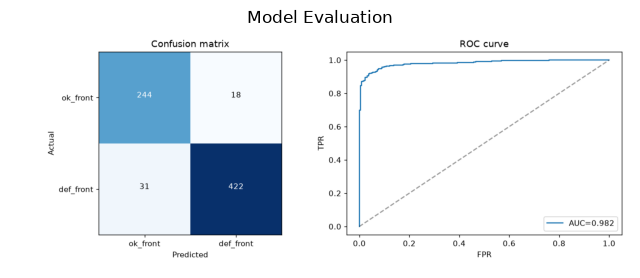

In [25]:
# TODO 3.1.1-3.1.2: load artifacts/metrics.json + show artifacts/model_eval.png
metrics = load(config.METRICS_PATH)
print("Test Metrics")
print(pd.DataFrame([metrics]))
img = mpimg.imread(config.ARTIFACT_DIR / "model_eval.png")
plt.figure(figsize=(8, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Model Evaluation")
plt.show()

## **Stage 3.2 — Model Registry & Promotion** <font color="red">[5 marks]</font>

- **3.2.1 — Best model registered in MLflow Registry [2]**
- **3.2.2 — Promotion to production alias + version history [3]**

**Objective:** Register and promote the best model.

**Implement in:** src/train.py (MLflow registry)

**Inputs → Outputs:** best run → registered model + @production alias

**TODO:** register_model(casting_defect_classifier) (3.2.1); set_registered_model_alias('production', v) with version history (3.2.2).

**Document here:** the registry version + alias (screenshot the MLflow Models page).

In [26]:
# TODO 3.2.1-3.2.2: MlflowClient().get_model_version_by_alias(config.REGISTERED_MODEL, 'production')
from mlflow import MlflowClient
client = MlflowClient()
versions = client.search_model_versions(f"name='{config.REGISTERED_MODEL}'")
print("Registered Model:", config.REGISTERED_MODEL)
for v in versions:
    print("Version:", v.version)

Registered Model: casting_defect_classifier
Version: 1


## **Stage 3.3 — FastAPI Inference Service** <font color="red">[6 marks]</font>

- **3.3.1 — Image /predict + /health + logging + validation [4]** — *to be done in app.py*
- **3.3.2 — Live call demonstrated in-notebook [2]** — *to be done in this notebook*

**Objective:** Serve the model behind an image API and demonstrate it.

**Implement in:** app.py (+ a TestClient demo here)

**Inputs → Outputs:** image upload → {label, prob_defect, confidence}; /health; predictions logged

**TODO:** implement /health + POST /predict (UploadFile) with validation (bad image 400, no-model 503) + logging (3.3.1, in app.py); demo with TestClient on a sample image (3.3.2, here).

**Document here:** the live request/response (TestClient output).

In [27]:
# TODO 3.3.2: with TestClient(app.app) as c: call /health and POST a sample image to /predict
from fastapi.testclient import TestClient
from pathlib import Path
import logging
import app as app_module

for name in ("httpx", "httpcore", "urllib3"):
    logging.getLogger(name).setLevel(logging.WARNING)

with TestClient(app_module.app) as client:
    print("GET /health ->", client.get("/health").json())
    for cls in ["ok_front", "def_front"]:
        img = sorted((config.DATA_DIR / "casting_data" / "test" / cls).glob("*.jpeg"))[0]
        with open(img, "rb") as f:
            response = client.post(
                "/predict",
                files={"file": (img.name, f.read(), "image/jpeg")})

        print(f"POST /predict [{cls}] ->", response.json())

GET /health -> {'status': 'ok', 'model_loaded': True, 'registered_model': 'casting_defect_classifier', 'classes': {'ok_front': 0, 'def_front': 1}, 'positive_class': 'def_front', 'test_metrics': {'accuracy': 0.9315, 'precision_defect': 0.9591, 'recall_defect': 0.9316, 'f1_defect': 0.9451, 'macro_f1': 0.9269, 'roc_auc': 0.9819, 'confusion_matrix': [[244, 18], [31, 422]], 'n': 715}}
POST /predict [ok_front] -> {'filename': 'cast_ok_0_10.jpeg', 'label': 'ok_front', 'is_defective': False, 'prob_defect': 0.4426, 'confidence': 0.5574}
POST /predict [def_front] -> {'filename': 'cast_def_0_1059.jpeg', 'label': 'def_front', 'is_defective': True, 'prob_defect': 0.6453, 'confidence': 0.6453}


## **Stage 3.4 — Containerisation & CI/CD** <font color="red">[7 marks]</font>

- **3.4.1 — Valid Dockerfile [3]** — *to be done in this notebook and the report*
- **3.4.2 — GitHub Actions CI + passing-test evidence [4]** — *to be done in this notebook and the report*

**Objective:** Containerise and automate tests.

**Implement in:** Dockerfile + .github/workflows/ci.yml (provided — review + evidence them)

**Inputs → Outputs:** code → Docker image; push/PR → CI runs pytest + docker build

**TODO:** show the Dockerfile (3.4.1); run pytest here + include a screenshot of the green CI run and successful docker build (3.4.2).

**Document here:** pytest output + Docker/CI screenshots **(Note: Don't add a repo link)**

In [22]:
# TODO 3.4.1-3.4.2: print Dockerfile + ci.yml; run pytest; embed your CI/Docker screenshots
